Adding project root to python path

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
sys.path.append(str(PROJECT_ROOT))

Imports

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from src.data_loader import DataLoader
from src.signals import MomentumSignals
from src.backtest import Backtester
from src.performance import PerformanceMetrics

loader = DataLoader()
signal_generator = MomentumSignals()
backtester = Backtester()
perf_calculator = PerformanceMetrics()

Defining tickers for the portfolio and downloading the data

In [3]:
TICKERS = [
    "AAPL", "MSFT", "AMZN", "NVDA", "JPM",  # equities
    "GLD",  # gold
    "TLT",  # bonds
    "UUP",  # USD
    "DBC"   # commodities
]

prices = loader.download_prices(TICKERS)
returns = loader.compute_returns(prices)

Compute signals for different time horizons

In [4]:
signals_dict = signal_generator.compute_multi_horizon_signals(prices)

Compute returns for all horizons

In [5]:
strategy_returns = backtester.compute_overlapping_returns(
    returns,
    signals_dict
)

portfolio_returns = backtester.aggregate_portfolio_returns(
    strategy_returns
)

cumulative_returns = backtester.compute_cumulative_returns(
    portfolio_returns
)

Compute volatility scaled returns for the 1Y horizon

In [6]:
scaled_returns = backtester.compute_vol_scaled_returns(
    returns,
    signals_dict[252]
)

scaled_portfolio = backtester.aggregate_portfolio_returns(
    scaled_returns
)

scaled_cum = backtester.compute_cumulative_returns(
    scaled_portfolio
)

Download benchmark data and align all start dates for charts

In [7]:
spy_prices = loader.download_prices(["SPY"])
spy_returns = loader.compute_returns(spy_prices)["SPY"]

start = spy_returns.index.min() + pd.DateOffset(years=1)

spy_returns = spy_returns.loc[spy_returns.index >= start]
spy_cum = (1 + spy_returns).cumprod()

aligned_strategy = cumulative_returns.loc[
    cumulative_returns.index >= start
]

aligned_scaled = scaled_cum.loc[
    scaled_cum.index >= start
]

Generate a chart comparing cumulative returns

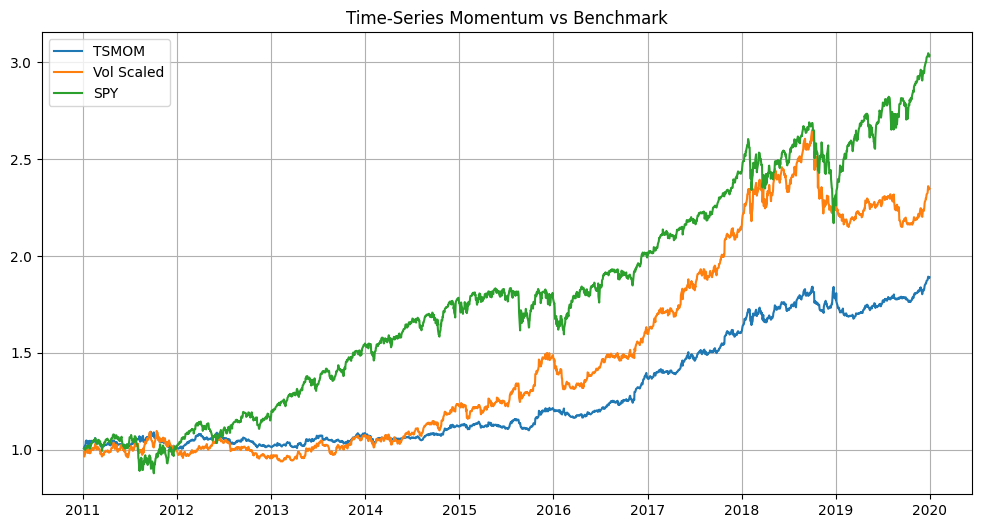

In [8]:
plt.figure(figsize=(12, 6))

plt.plot(aligned_strategy, label="TSMOM")
plt.plot(aligned_scaled, label="Vol Scaled")
plt.plot(spy_cum, label="SPY")

plt.title("Time-Series Momentum vs Benchmark")
plt.legend()
plt.grid(True)
plt.show()

Generate the different horizons returns

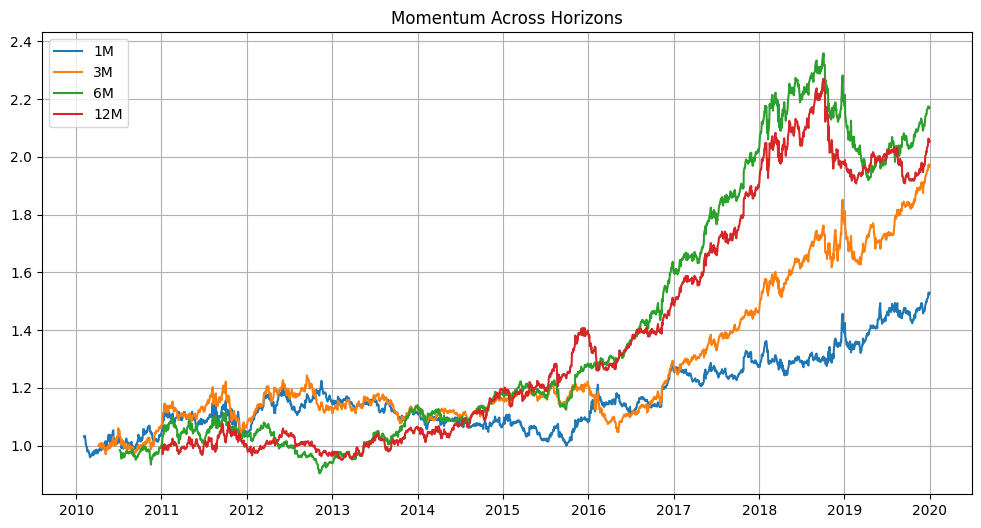

In [9]:
plt.figure(figsize=(12, 6))

for h, sig in signals_dict.items():
    strat = backtester.aggregate_portfolio_returns(sig * returns)
    cum = backtester.compute_cumulative_returns(strat)
    plt.plot(cum, label=f"{h//21}M")

plt.legend()
plt.title("Momentum Across Horizons")
plt.grid(True)
plt.show()

Split the returns into the long and short leg

In [10]:
signals = signals_dict[252]

long_mask = signals > 0
short_mask = signals < 0

long_returns = returns.where(long_mask)
short_returns = -returns.where(short_mask)

long_portfolio = long_returns.mean(axis=1)
short_portfolio = short_returns.mean(axis=1)

long_cum = (1 + long_portfolio.fillna(0)).cumprod()
short_cum = (1 + short_portfolio.fillna(0)).cumprod()

Chart the returns for the two legs of the strategy

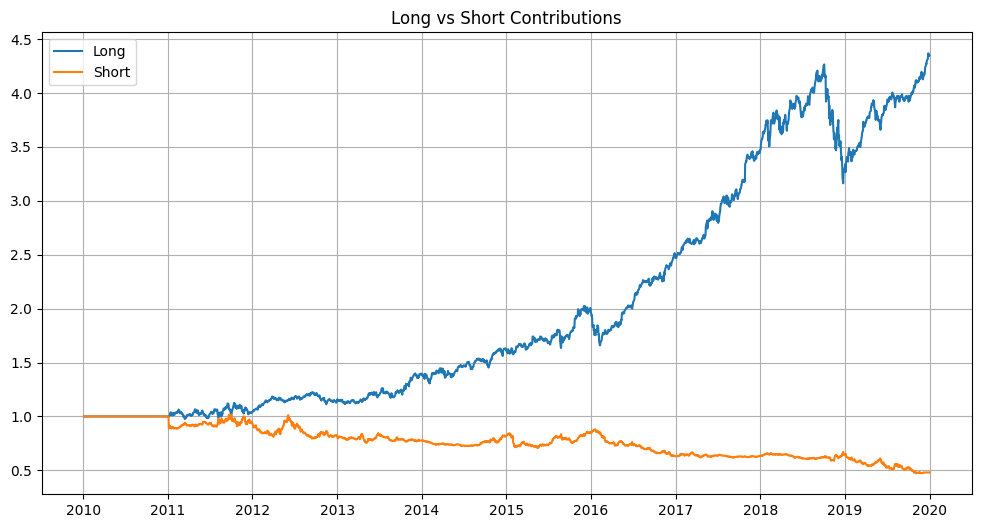

In [11]:
plt.figure(figsize=(12, 6))

plt.plot(long_cum, label="Long")
plt.plot(short_cum, label="Short")

plt.title("Long vs Short Contributions")
plt.legend()
plt.grid(True)
plt.show()

Calculate and chart maximum drawdown

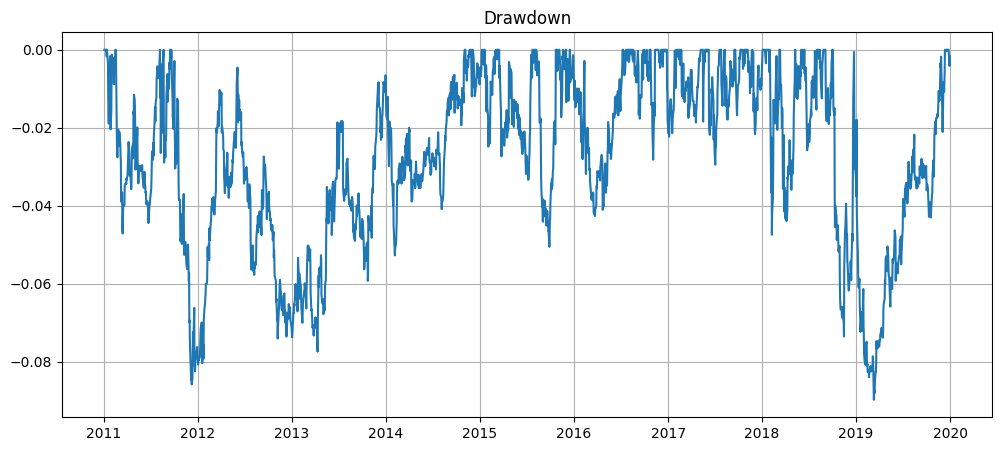

In [12]:
drawdown = (
    cumulative_returns /
    cumulative_returns.cummax()
) - 1

plt.figure(figsize=(12, 5))
plt.plot(drawdown)
plt.title("Drawdown")
plt.grid(True)
plt.show()

Generate performance metrics for the strategies

In [13]:
print("TSMOM:")
print("Return:", perf_calculator.annualized_return(portfolio_returns))
print("Vol:", perf_calculator.annualized_volatility(portfolio_returns))
print("Sharpe:", perf_calculator.sharpe_ratio(portfolio_returns))
print("Max DD:", perf_calculator.max_drawdown(cumulative_returns))

print("\nVol Scaled:")
print("Return:", perf_calculator.annualized_return(scaled_portfolio))
print("Sharpe:", perf_calculator.sharpe_ratio(scaled_portfolio))
print("Max DD:", perf_calculator.max_drawdown(scaled_cum))

print("\nSPY:")
print("Return:", perf_calculator.annualized_return(spy_returns))
print("Sharpe:", perf_calculator.sharpe_ratio(spy_returns))

TSMOM:
Return: 0.07342606198599362
Vol: 0.07099680599743763
Sharpe: 1.0342164123361222
Max DD: -0.08969775498243412

Vol Scaled:
Return: 0.10179951172544946
Sharpe: 0.8751466746397382
Max DD: -0.18933733946454281

SPY:
Return: 0.13400961712501178
Sharpe: 0.9370530379799162
